In [ ]:
# SUPERVISED MACHINE LEARNING -> CLASSIFICATION MODEL ->LOGISTIC REGRESSION

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train_df = pd.read_csv(r"/content/Titanic_train.csv")
test_df = pd.read_csv(r"/content/Titanic_test.csv")

In [ ]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
train_df.shape

(891, 12)

In [ ]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
# PASSENGERID AND NAME CANT GIVE USEFULL DATA TO THE MODEL

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
train_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# AGE AND CABIN HAS LOT OF NULL VALUES, AGE CAN BE FILLED WITH MEAN/MEDIAN AND EMBARKED CAN BE FILLED WITH MODE

In [ ]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# THE MEANS AND MEDIAN ARE HAVING VARIANCE AND I CAN SEE STANDARD DEVIATION HAVING HUGE VALUES

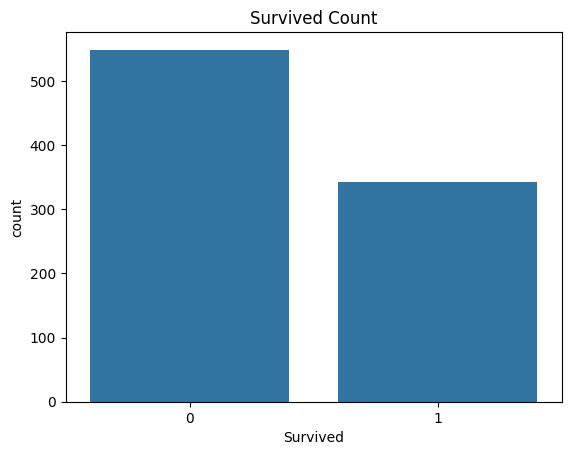

In [ ]:
sns.countplot(data=train_df,x='Survived')
plt.title("Survived Count")
plt.show()

In [ ]:
# NUMBER OF PEOPLE WHO DID NOT SURVIVE ARE MORE

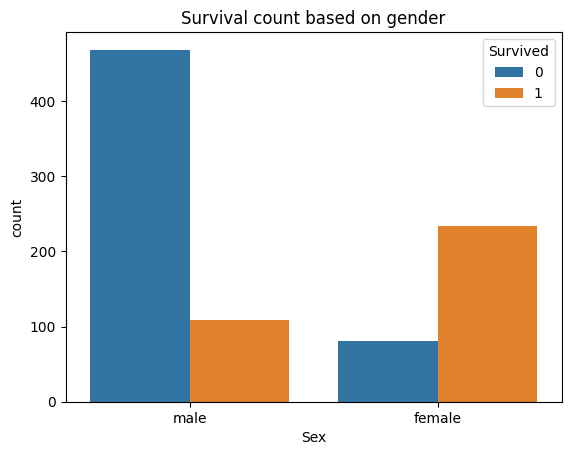

In [ ]:
sns.countplot(data=train_df, x='Sex', hue='Survived')
plt.title("Survival count based on gender")
plt.show()

In [ ]:
# SEEING THE GRAPH WE CAN SAY FEMALES SURVIVED MORE

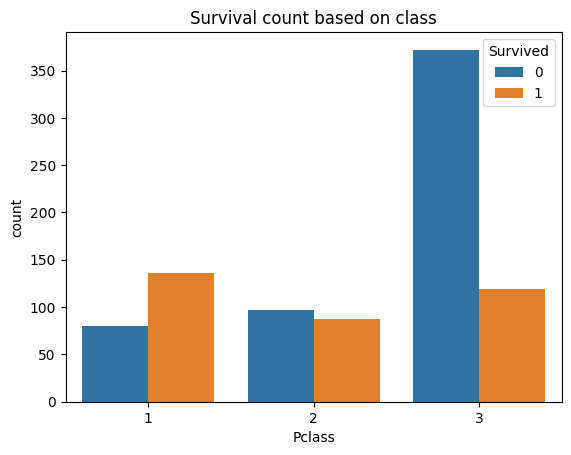

In [ ]:
sns.countplot(data=train_df, x='Pclass', hue='Survived')
plt.title("Survival count based on class")
plt.show()

In [ ]:
# THE SURVIVAL OF PCLASS 1 IS MORE THAN ANY OTHER

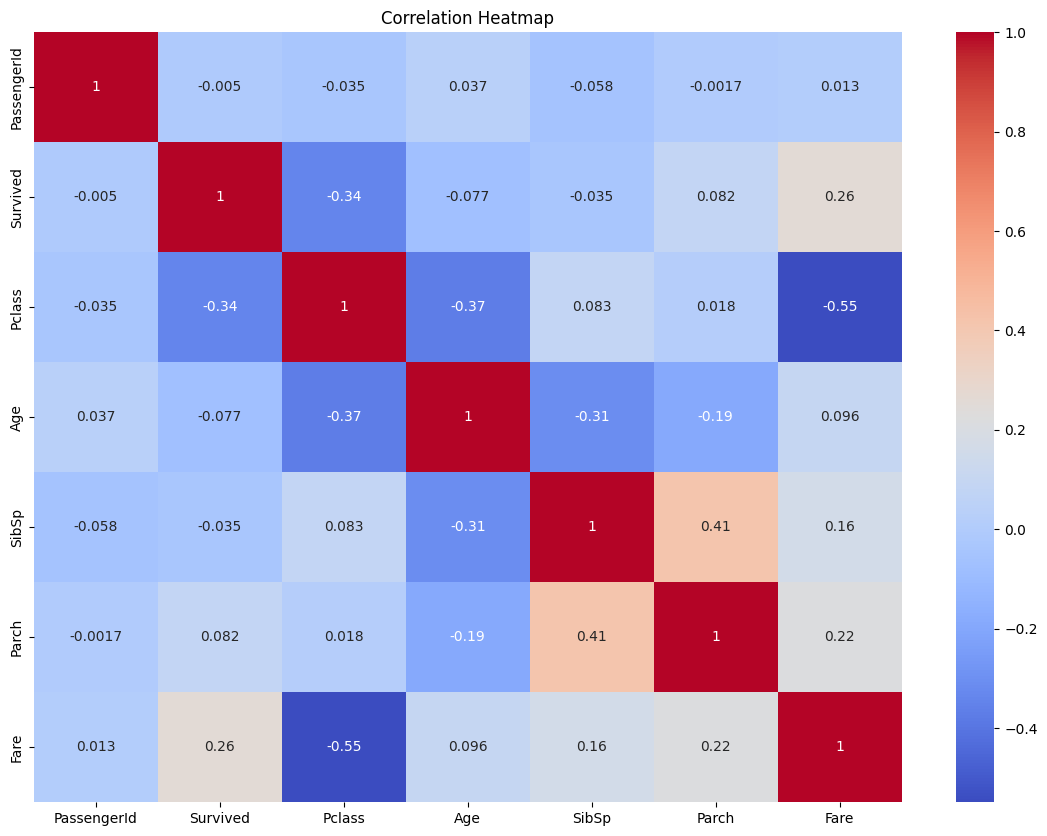

In [ ]:
plt.figure(figsize=(14,10))
sns.heatmap(train_df.corr(numeric_only=True),cmap='coolwarm',annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
"""
PCLASS AND FARE , SURVIVED AND PCLASS, PCLASS AND AGE, PCLASS AND SIBSP ALL THESES ARE
NEGATIVELY CORRELATED MEANS ONE INCREASES THAN OTHER MIGHT DECREASE.
FARE AND SURVIVED SHOWS POSITIVE CORRELATION AND FARE AND PARCH SHOW SOME POSITIVE CORRELATION
"""

'\nPCLASS AND FARE , SURVIVED AND PCLASS, PCLASS AND AGE, PCLASS AND SIBSP ALL THESES ARE\nNEGATIVELY CORRELATED MEANS ONE INCREASES THAN OTHER MIGHT DECREASE.\nFARE AND SURVIVED SHOWS POSITIVE CORRELATION AND FARE AND PARCH SHOW SOME POSITIVE CORRELATION\n'

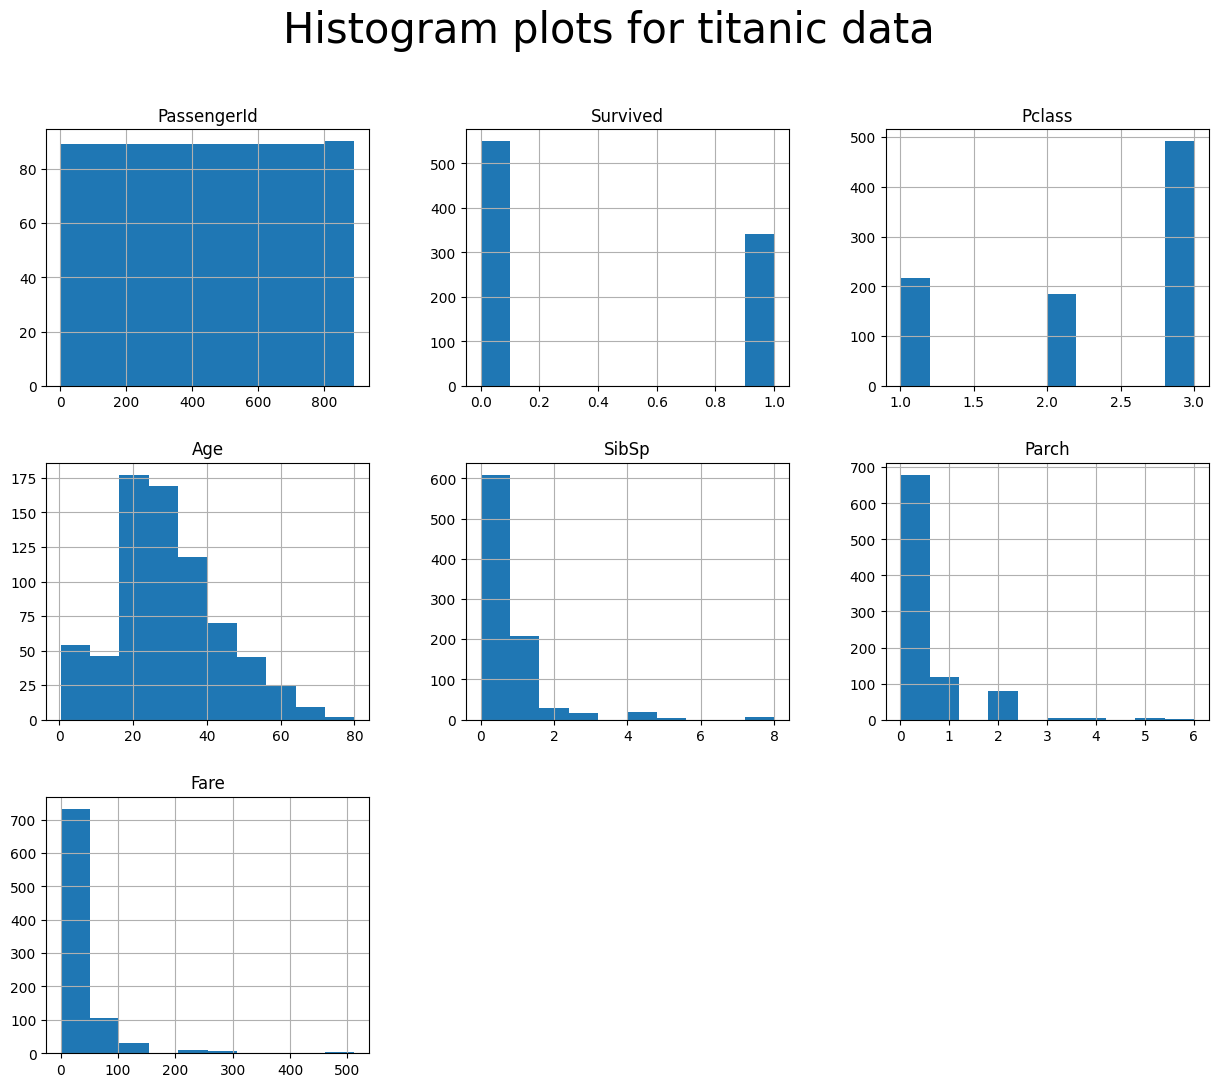

In [ ]:
train_df.hist(figsize=(15,12))
plt.suptitle("Histogram plots for titanic data",fontsize=30)
plt.show()

In [ ]:
"""
 PASSENGERID IS INDEX AND HENCE DROPING THAT IS BEST CHOICE, AND I CAN SEE SOME ARE BIMODEL/MULTIMODEL
 DISTRIBUTION, SIBSP/PARCH/AGE/FARE HAVE RIGHT SKEWNESS. ALL OF THEM ARE ORIGINAL DATA BUT FARE CAN HAVE
 OUTLIER STATING ONLY FEW PAID HUGE AMOUNTS
 """

'\n PASSENGERID IS INDEX AND HENCE DROPING THAT IS BEST CHOICE, AND I CAN SEE SOME ARE BIMODEL/MULTIMODEL\n DISTRIBUTION, SIBSP/PARCH/AGE/FARE HAVE RIGHT SKEWNESS. ALL OF THEM ARE ORIGINAL DATA BUT FARE CAN HAVE\n OUTLIER STATING ONLY FEW PAID HUGE AMOUNTS\n '

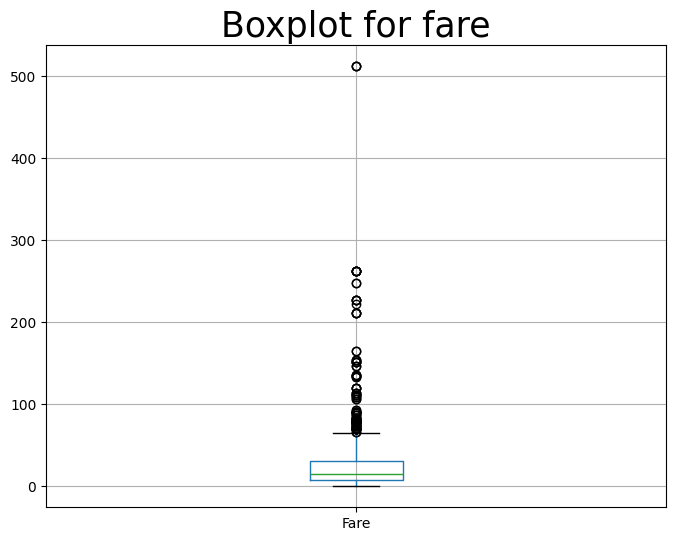

In [ ]:
# USING BOXPLOT TO CHECK OUTLIERS IN FAIR FEATURE
train_df[['Fare']].boxplot(figsize=(8,6))
plt.title("Boxplot for fare",fontsize=25)
plt.show()

In [ ]:
# MOST OF THE FARE DATA LIES LITTLE ABOVE ZERO AND WE CAN CLEARLY SEE THE PRESENT OF OUTLIERS

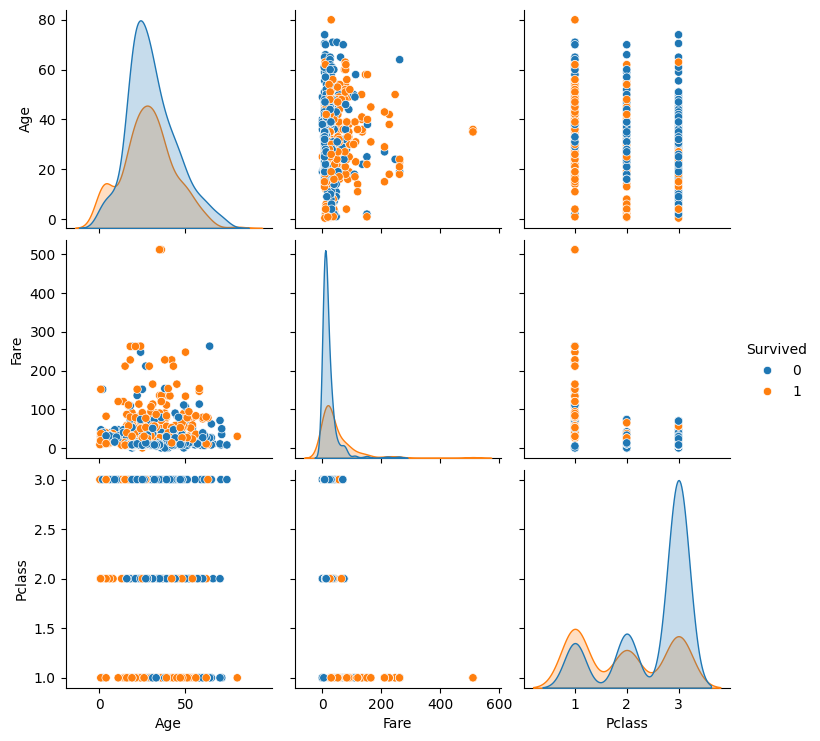

In [ ]:
sns.pairplot(train_df[['Survived', 'Age', 'Fare', 'Pclass']], hue='Survived')
plt.show()

In [ ]:
"""
 THE PAIR PLOT GIVES PAIRWISE RELATION HERE I CAN SEE THAT PEOPLE HAVING LESS AGE(CHILDREN)
 SURVIVED MORE AND FEW WHO PAID MORE HAD MORE CHANCES OF SURVIVING AND PEOPLE IN PCLASS 3 DIED MORE
 """

'\n THE PAIR PLOT GIVES PAIRWISE RELATION HERE I CAN SEE THAT PEOPLE HAVING LESS AGE(CHILDREN)\n SURVIVED MORE AND FEW WHO PAID MORE HAD MORE CHANCES OF SURVIVING AND PEOPLE IN PCLASS 3 DIED MORE\n '

In [ ]:
# DATA PREPROCESSING

In [ ]:
train_df = train_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'],axis=1)
test_df = test_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'],axis=1)

In [ ]:
train_df['Age'].fillna(train_df['Age'].median(),inplace=True)
test_df['Age'].fillna(test_df['Age'].median(),inplace=True)

/tmp/ipython-input-3029343883.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Age'].fillna(train_df['Age'].median(),inplace=True)
/tmp/ipython-input-3029343883.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

In [ ]:
train_df['Embarked'].fillna(train_df['Embarked'].mode()[0],inplace=True)
test_df['Embarked'].fillna(test_df['Embarked'].mode()[0],inplace=True)

/tmp/ipython-input-2004121452.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Embarked'].fillna(train_df['Embarked'].mode()[0],inplace=True)
/tmp/ipython-input-2004121452.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

In [ ]:
train_df['Sex']  = train_df['Sex'].map({'male':0, 'female':1})
test_df['Sex']  = test_df['Sex'].map({'male':0, 'female':1})

In [ ]:
train_df = pd.get_dummies(train_df, columns=['Embarked'],drop_first=True)
test_df = pd.get_dummies(test_df, columns=['Embarked'],drop_first=True)

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked_Q  891 non-null    bool   
 8   Embarked_S  891 non-null    bool   
dtypes: bool(2), float64(2), int64(5)
memory usage: 50.6 KB


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      418 non-null    int64  
 1   Sex         418 non-null    int64  
 2   Age         418 non-null    float64
 3   SibSp       418 non-null    int64  
 4   Parch       418 non-null    int64  
 5   Fare        417 non-null    float64
 6   Embarked_Q  418 non-null    bool   
 7   Embarked_S  418 non-null    bool   
dtypes: bool(2), float64(2), int64(4)
memory usage: 20.5 KB


In [ ]:
train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [ ]:
train_df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked_Q,0
Embarked_S,0


In [ ]:
test_df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,3,0,34.5,0,0,7.8292,True,False
1,3,1,47.0,1,0,7.0000,False,True
2,2,0,62.0,0,0,9.6875,True,False
3,3,0,27.0,0,0,8.6625,False,True
4,3,1,22.0,1,1,12.2875,False,True


In [ ]:
test_df.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,1
Embarked_Q,0
Embarked_S,0


In [ ]:
test_df['Fare'].fillna(test_df['Fare'].mean(),inplace=True)

/tmp/ipython-input-498746240.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df['Fare'].fillna(test_df['Fare'].mean(),inplace=True)


In [ ]:
# MODEL BUILDING
# FEATURE SPLITING
x = train_df.drop('Survived',axis=1)
y = train_df['Survived']

In [ ]:
from sklearn.model_selection import train_test_split as tts
from sklearn.linear_model import LogisticRegression as lr

In [ ]:
x_train, x_test, y_train, y_test = tts(x,y,random_state=32,test_size=0.2)
model = lr(max_iter=1000)
model.fit(x_train,y_train)
pred = model.predict(x_test)
prob = model.predict_proba(x_test)[:,1]

In [ ]:
test_pred = model.predict(test_df)
test_pred

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [ ]:
# MODEL EVALUATION
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
acc  = accuracy_score(y_test,pred)
prec = precision_score(y_test,pred)
rec =  recall_score(y_test,pred)
f1  =  f1_score(y_test,pred)

print("Accuracy Score: ",acc)
print("Precision Score: ",prec)
print("Recall Score: ",rec)
print("F1 Score: ",f1)

Accuracy Score:  0.7821229050279329
Precision Score:  0.7424242424242424
Recall Score:  0.6901408450704225
F1 Score:  0.7153284671532847


In [ ]:
# MODEL HAS A GOOD ACCURACY SCORE OF 78 PERCENTAGE FOR AN LOGISTIC REGRESSION MODEL
# AND HAS A F1 SCORE OF 71 PERCENTAGE WHICH SHOWS A GOOD BALANCE BETWEEN RECALL AND PRECISION

ROC-AUC Score: 0.8563510693792383


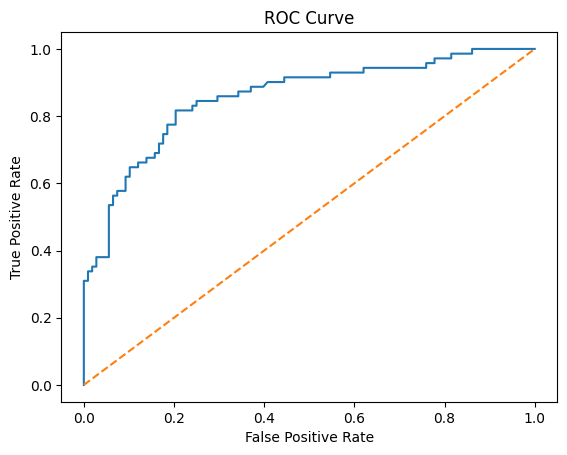

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
roc_auc = roc_auc_score(y_test,prob)
print("ROC-AUC Score:", roc_auc)
fpr, tpr, _ = roc_curve(y_test,prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [ ]:
# BLUE LINE IS ABOVE DIAGONAL LINE WHICH MEANS MODEL IS PREDICTING GOOD ENOUGH

In [ ]:
# INTERPRETATION OF COEFFICIENT
coeff_df = pd.DataFrame({'Features':x.columns, 'Coefficient':model.coef_[0]})
coeff_df

,Features,Coefficient
0,Pclass,-1.013933
1,Sex,2.534219
2,Age,-0.038267
3,SibSp,-0.377715
4,Parch,-0.049663
5,Fare,0.003557
6,Embarked_Q,-0.118812
7,Embarked_S,-0.494953


In [ ]:
''' WE CAN CLEARLY SEE THE COEFFICIENT OF SEX AND FARE. IN SEX WE MAPPED FEMALE TO 1 SO SURVIVAL OF FEMALE IS
MORE THAN MEN AND AS THE FARE INCREASES THE SURVIVAL CHANCES INCREASES'''

' WE CAN CLEARLY SEE THE COEFFICIENT OF SEX AND FARE. IN SEX WE MAPPED FEMALE TO 1 SO SURVIVAL OF FEMALE IS\nMORE THAN MEN AND AS THE FARE INCREASES THE SURVIVAL CHANCES INCREASES'

In [ ]:
# DEPLOYMENT OF MODEL

In [ ]:
import joblib
joblib.dump(model, 'titanic.pkl')

['titanic.pkl']

In [ ]:
# TRAINED MODEL SAVED IN PKL FILE TO USE IN DEPLOYMENT

In [ ]:
# THE ONLINE DEPLOYED URL
# https://titanicappapp-aoewxulydcwraucxh3efik.streamlit.app/

In [ ]:
"""
INTERVIEW QUESTIONS...

PRECISION AND RECALL ARE METRICS USED TO EVALUATE
PRECISION(QUALITY) :- THIS METRIC IS USED TO CHECK HOW MANY OF THE MODELS PREDICTIONS ARE ACTUALLY TRUE.

RECALL(QUANTITY) :- THIS METRIC IS USED TO CHECK HOW MANY OF THE ACTUAL TRUE PREDICTIONS ARE PREDICTED CORRECTLY.

CROSS VALIDATION AND ITS IMPORTANCE IN BINARY CLASSIFICATION.
CROSS VALIDATION(CV) : THIS IS A RESAMPLING TECHNIQUE USED TO GENRALIZE THE MODEL BY UISNG DIFFERENT PARTS OF
    DATASET FOR TRANING AND TESTING.

IMPORTANCE IN BINARY CLASSIFICATION
-> THIS IS USED IN REDUCING OVERFITTING PROBLEMS
-> RELIABLE METRICS WHEN SCORES ACROSS ALL RUNS ARE USED FOR ESTIMATION
-> EFFICIENT USE OF DATA ESPECIALLY WHEN DATASET IS SMALL
"""